<a href="https://colab.research.google.com/github/Kusum067/Engine_Health_Prediction_ML/blob/main/Engine_Health_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

**Problem Statement : Automotive vechicles engine health prediction for maintainance**

Data Gathering

In [ ]:
df = pd.read_csv('engine_data.csv')
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [ ]:
df.shape

(19535, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [ ]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [ ]:
df.isna().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Engine Condition'].value_counts()

,count
Engine Condition,
1,12317
0,7218


**Graph**

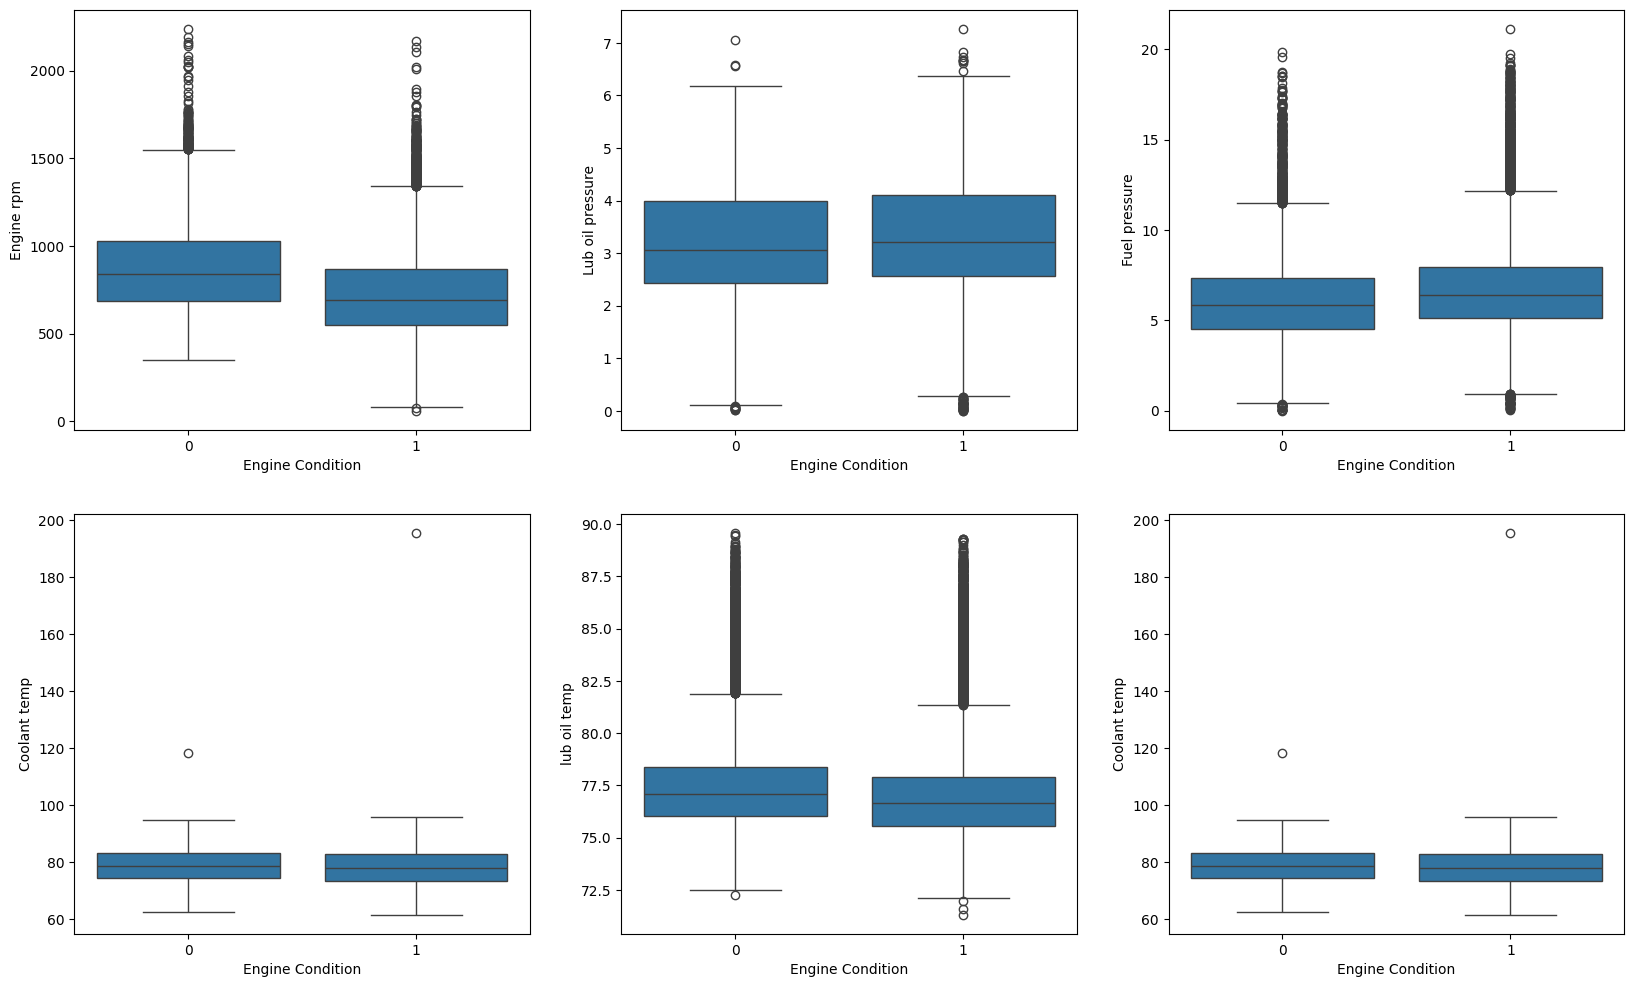

In [ ]:
plt.figure(figsize=(20,12))
plt.subplot(2,3,1)
sns.boxplot(y = 'Engine rpm', x = 'Engine Condition', data = df)
plt.subplot(2,3,2)
sns.boxplot(y = 'Lub oil pressure', x = 'Engine Condition', data = df)
plt.subplot(2,3,3)
sns.boxplot(y = 'Fuel pressure', x = 'Engine Condition', data = df)
plt.subplot(2,3,4)
sns.boxplot(y = 'Coolant temp', x = 'Engine Condition', data = df)
plt.subplot(2,3,5)
sns.boxplot(y = 'lub oil temp', x = 'Engine Condition', data = df)
plt.subplot(2,3,6)
sns.boxplot(y = 'Coolant temp', x = 'Engine Condition', data = df)
plt.show()

**Train Test Split data**

In [ ]:
def train_test_split_and_features(df):
  y = df["Engine Condition"]
  x = df.drop(['Engine Condition'], axis=1)
  xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.20, random_state=0)
  print(x.head(5))
  print(x.columns)
  features = list(x.columns)
  return xtrain, xtest, ytrain, ytest, features

In [ ]:
xtrain, xtest, ytrain, ytest, features = train_test_split_and_features(df)

   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         700          2.493592      11.790927          3.178981   
1         876          2.941606      16.193866          2.464504   
2         520          2.961746       6.553147          1.064347   
3         473          3.707835      19.510172          3.727455   
4         619          5.672919      15.738871          2.052251   

   lub oil temp  Coolant temp  
0     84.144163     81.632187  
1     77.640934     82.445724  
2     77.752266     79.645777  
3     74.129907     71.774629  
4     78.396989     87.000225  
Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp'],
      dtype='object')


**Fit and Evaluate model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

**Problem Statement : Automotive vechicles engine health prediction for maintainance**

Data Gathering

In [ ]:
df = pd.read_csv('engine_data.csv')
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [ ]:
df.shape

(19535, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


In [ ]:
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [ ]:
df.isna().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Engine Condition'].value_counts()

,count
Engine Condition,
1,12317
0,7218


**Graph**

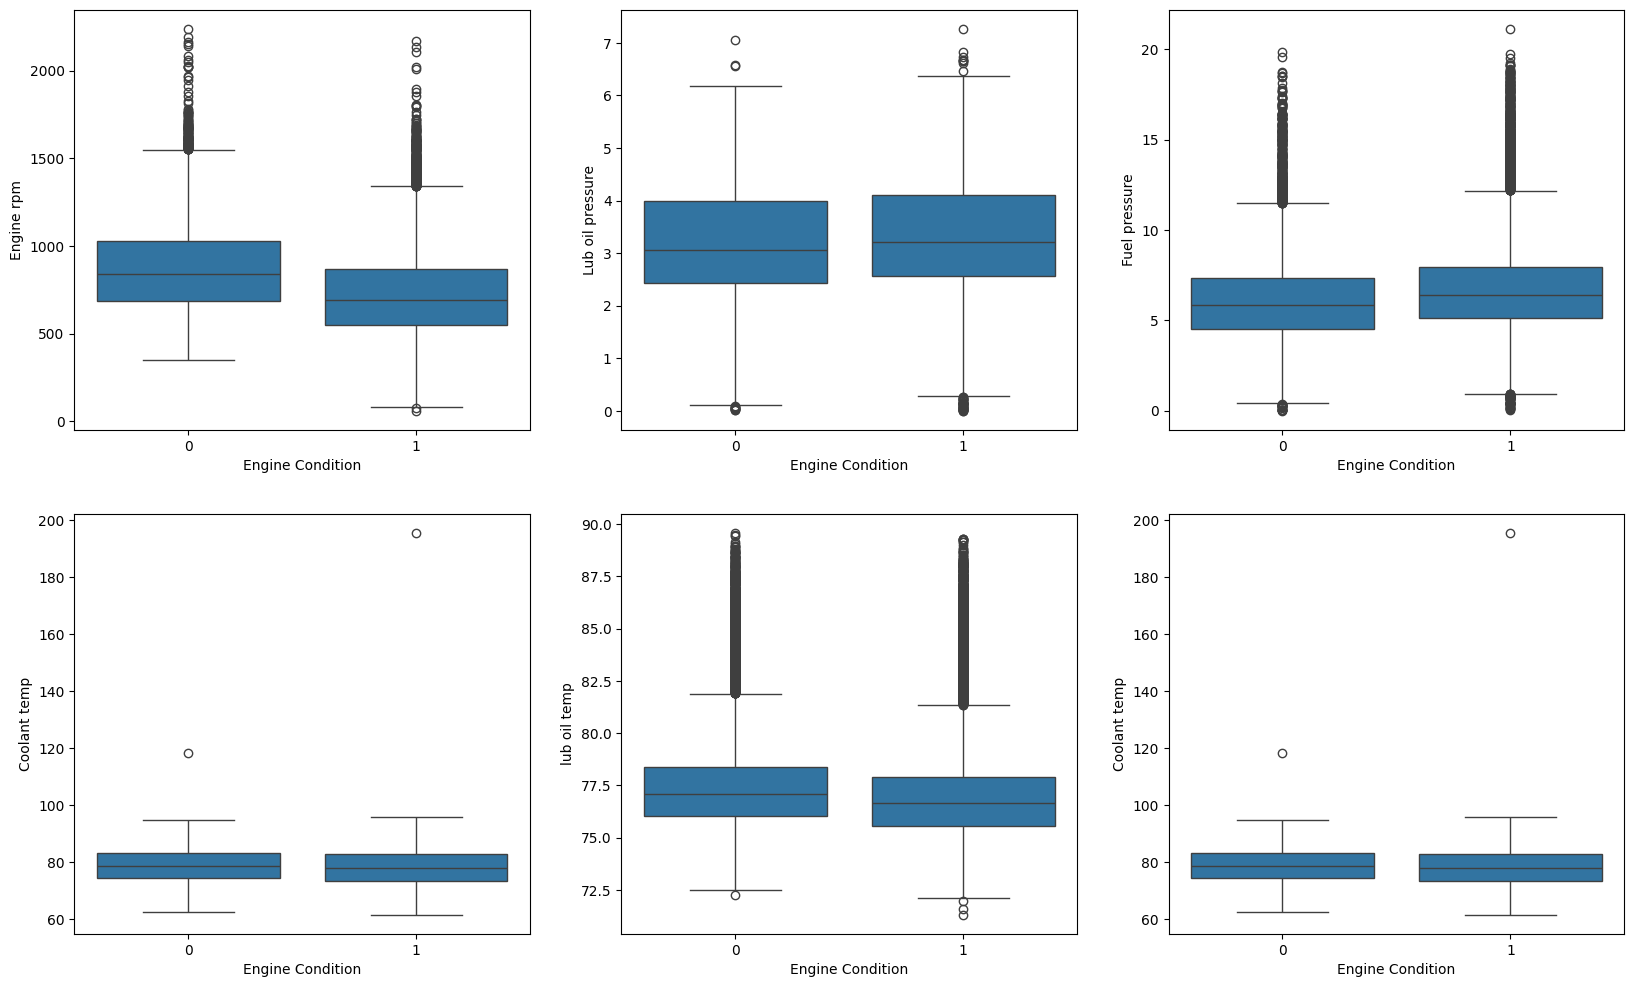

In [ ]:
plt.figure(figsize=(20,12))
plt.subplot(2,3,1)
sns.boxplot(y = 'Engine rpm', x = 'Engine Condition', data = df)
plt.subplot(2,3,2)
sns.boxplot(y = 'Lub oil pressure', x = 'Engine Condition', data = df)
plt.subplot(2,3,3)
sns.boxplot(y = 'Fuel pressure', x = 'Engine Condition', data = df)
plt.subplot(2,3,4)
sns.boxplot(y = 'Coolant temp', x = 'Engine Condition', data = df)
plt.subplot(2,3,5)
sns.boxplot(y = 'lub oil temp', x = 'Engine Condition', data = df)
plt.subplot(2,3,6)
sns.boxplot(y = 'Coolant temp', x = 'Engine Condition', data = df)
plt.show()

**Train Test Split data**

In [ ]:
def train_test_split_and_features(df):
  y = df["Engine Condition"]
  x = df.drop(['Engine Condition'], axis=1)
  xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.20, random_state=0)
  print(x.head(5))
  print(x.columns)
  features = list(x.columns)
  return xtrain, xtest, ytrain, ytest, features

In [ ]:
xtrain, xtest, ytrain, ytest, features = train_test_split_and_features(df)

   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         700          2.493592      11.790927          3.178981   
1         876          2.941606      16.193866          2.464504   
2         520          2.961746       6.553147          1.064347   
3         473          3.707835      19.510172          3.727455   
4         619          5.672919      15.738871          2.052251   

   lub oil temp  Coolant temp  
0     84.144163     81.632187  
1     77.640934     82.445724  
2     77.752266     79.645777  
3     74.129907     71.774629  
4     78.396989     87.000225  
Index(['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure',
       'lub oil temp', 'Coolant temp'],
      dtype='object')


**Fit and Evaluate model**

In [ ]:
def fit_and_evaluate_model(xtrain, xtest, ytrain, ytest, max_depth=5, min_samples_split=0.01, max_features=0.8, max_samples=0.8):
  random_forest = RandomForestClassifier(random_state=0,\
                                         max_depth=max_depth,\
                                         min_samples_split=min_samples_split,\
                                         max_features=max_features,
                                         max_samples=max_samples)
  model = random_forest.fit(xtrain, ytrain)
  random_forest_predict = random_forest.predict(xtest)
  random_forest_conf_matrix = confusion_matrix(ytest, random_forest_predict)
  random_forest_acc_score = accuracy_score(ytest, random_forest_predict)
  print("Confusion Matrix")
  print(random_forest_conf_matrix)
  print("\n")
  print("Accuracy of Random Forest Model : ", random_forest_acc_score*100, '\n')
  print(classification_report(ytest, random_forest_predict))
  return model

In [ ]:
model = fit_and_evaluate_model(xtrain, xtest, ytrain, ytest)

Confusion Matrix
[[ 507  904]
 [ 359 2137]]


Accuracy of Random Forest Model :  67.67340670591247 

              precision    recall  f1-score   support

           0       0.59      0.36      0.45      1411
           1       0.70      0.86      0.77      2496

    accuracy                           0.68      3907
   macro avg       0.64      0.61      0.61      3907
weighted avg       0.66      0.68      0.65      3907



In [ ]:
importances = pd.DataFrame(model.feature_importances_)
importances['features'] = features
importances.columns = ['importance', 'features']
importances.sort_values(by='importance', ascending=True, inplace=True)

In [ ]:
importances.head(10)

,importance,features
5,0.017678,Coolant temp
3,0.024955,Coolant pressure
1,0.060382,Lub oil pressure
4,0.097345,lub oil temp
2,0.163428,Fuel pressure
0,0.636212,Engine rpm


**Feature Importance**

<BarContainer object of 6 artists>

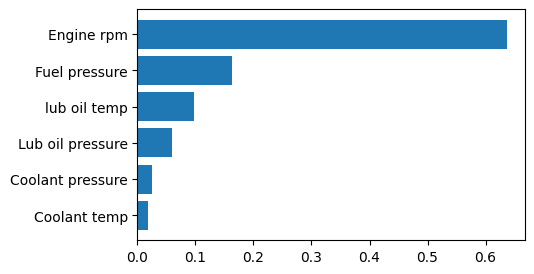

In [ ]:
plt.figure(figsize=(5,3))
plt.barh(importances.features, importances.importance)